# Variational Autoencoder (VAE) Latent Clustering

Variational Autoencoders (VAEs) compress inputs into a continuous, structured probability distribution space defined by mean ($\mu$) and standard deviation ($\sigma$) parameters. Sampling from this space allows generation of new data coordinates. This notebook implements a VAE in PyTorch to compress synthetic pixel grid digit patterns into a 2D latent space, mapping class distributions.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generate simulated handwritten-like digit pixel sequences (3 classes, 8x8 pixels)
np.random.seed(64)
n_samples = 600

# Class 0: Vertical bars
# Class 1: Horizontal bars
# Class 2: Diagonal bars
X_list, y_list = [], []
for _ in range(n_samples):
    digit_type = np.random.randint(0, 3)
    grid = np.random.normal(0, 0.05, (8, 8))
    
    if digit_type == 0:
        grid[:, 3:5] += 0.8  # Vertical bar
    elif digit_type == 1:
        grid[3:5, :] += 0.8  # Horizontal bar
    elif digit_type == 2:
        np.fill_diagonal(grid, 0.8) # Diagonal bar
        
    X_list.append(grid.flatten())
    y_list.append(digit_type)

X_data = np.array(X_list, dtype=np.float32)
y_data = np.array(y_list, dtype=np.int64)

# Normalize inputs to [0, 1]
X_data = (X_data - X_data.min()) / (X_data.max() - X_data.min())
X_tensor = torch.FloatTensor(X_data)

print("Dataset size:", X_data.shape)



Dataset size: (600, 64)


## VAE Architecture with Reparameterization Trick

We implement the VAE network in PyTorch:
1. **Encoder**: Compresses 64 features to mean ($\mu$) and log-variance ($\log \sigma^2$) output coordinate representations.
2. **Reparameterization Trick**: Samples latent vector $z = \mu + \epsilon \odot \sigma$ using normal random distribution inputs.
3. **Decoder**: Reconstructs inputs from the latent coordinates.



In [2]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim=64, latent_dim=2):
        super(VariationalAutoencoder, self).__init__()
        
        # Encoder layers
        self.fc_shared = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        
        # Decoder layers
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim),
            nn.Sigmoid()
        )
        
    def encode(self, x):
        h = self.fc_shared(x)
        return self.fc_mu(h), self.fc_logvar(h)
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
        
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

model = VariationalAutoencoder(input_dim=64, latent_dim=2)
optimizer = optim.Adam(model.parameters(), lr=0.01)



## Evidence Lower Bound (ELBO) Loss & Training

VAE training loss optimizes reconstruction quality and regularizes the latent space distribution against standard normal distributions:
$$\text{Loss} = \text{ReconstructionLoss} + \text{Kullback-LeiblerDivergence}$$



In [3]:
def vae_loss_fn(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence equation
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.1 * kld_loss # Apply scale penalty factor

epochs = 50
model.train()

for epoch in range(1, epochs + 1):
    recon_batch, mu, logvar = model(X_tensor)
    loss = vae_loss_fn(recon_batch, X_tensor, mu, logvar)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d}/{epochs} | Total VAE ELBO Loss: {loss.item():.2f}")



Epoch 10/50 | Total VAE ELBO Loss: 2408.45
Epoch 20/50 | Total VAE ELBO Loss: 2029.29
Epoch 30/50 | Total VAE ELBO Loss: 1236.01
Epoch 40/50 | Total VAE ELBO Loss: 753.59
Epoch 50/50 | Total VAE ELBO Loss: 426.49


## 2D Latent Clustering Space Plot

We run the encoder on all dataset inputs to extract the 2D mean ($\mu$) coordinate vectors, and scatter plot these latent coordinate points using Matplotlib colored by classes to evaluate clustering quality.



<cell>:14: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



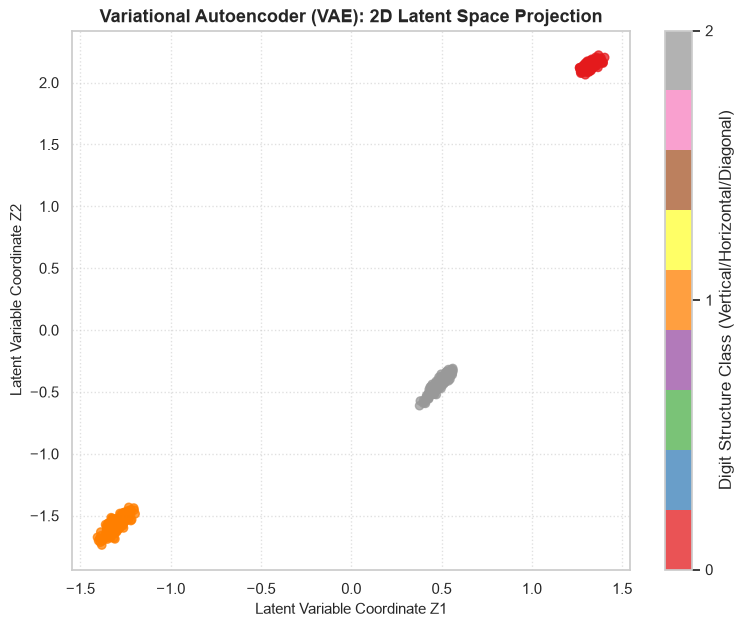

In [4]:
model.eval()
with torch.no_grad():
    mu_coords, _ = model.encode(X_tensor)
    mu_coords = mu_coords.numpy()

plt.figure(figsize=(9, 7))
scatter = plt.scatter(mu_coords[:, 0], mu_coords[:, 1], c=y_data, cmap='Set1', s=35, alpha=0.75)

plt.title('Variational Autoencoder (VAE): 2D Latent Space Projection', fontsize=13, fontweight='bold')
plt.xlabel('Latent Variable Coordinate Z1', fontsize=11)
plt.ylabel('Latent Variable Coordinate Z2', fontsize=11)
plt.colorbar(scatter, ticks=[0, 1, 2], label='Digit Structure Class (Vertical/Horizontal/Diagonal)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
